# XGBoost Baseline — Cáceres Solar Forecast

Train XGBoost as a simpler, non-sequential baseline to validate TFT's temporal modelling.

- Uses the **exact same processed data** as TFT (z-score normalized, same train/val/test splits)
- Each timestep treated independently (no lag features, no sequence windowing)
- **Fair comparison constraint:** XGBoost only uses features available at forecast time
  (i.e., only `known_future` features — the same features the TFT decoder sees)
- Two variants: **Standard** (9 calendar/solar features) and **NWP** (16 known-future features)
- Optuna HP search with 15 trials per variant (matching TFT search effort)

**Why restrict features?** In a real day-ahead forecast scenario, observed ERA5 weather
(temperature, radiation, etc.) is not available for future hours. Only deterministic features
(calendar, solar geometry) and NWP forecasts are known ahead of time. Using observed weather
at the target timestep would give XGBoost an unfair advantage over TFT, which only sees
these observations in its encoder (past 168h), never in its decoder (future 24h).

In [1]:
import os
import json
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\nicol\Documents\ML-solar-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Standard Data

In [2]:
DATA_DIR = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models', 'xgboost')
os.makedirs(MODEL_DIR, exist_ok=True)

# Load standard processed splits
train = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'), parse_dates=['datetime_utc'], index_col='datetime_utc')
val   = pd.read_csv(os.path.join(DATA_DIR, 'val_processed.csv'),   parse_dates=['datetime_utc'], index_col='datetime_utc')
test  = pd.read_csv(os.path.join(DATA_DIR, 'test_processed.csv'),  parse_dates=['datetime_utc'], index_col='datetime_utc')

# Load preprocessing params for denormalization
with open(os.path.join(DATA_DIR, 'preprocessing_params.json')) as f:
    params = json.load(f)
TARGET_MEAN = params['target_mean']
TARGET_STD  = params['target_std']

TARGET = 'pv_generation_mwh'

# Fair comparison: only use features available at forecast time (known_future).
# These match exactly what the TFT standard decoder sees.
# Observed ERA5 weather (temperature, radiation, etc.) is NOT available for future hours.
FEATURES = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi',
]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target mean: {TARGET_MEAN:.2f} MWh, Target std: {TARGET_STD:.2f} MWh')
print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

X_train, y_train = train[FEATURES].values, train[TARGET].values
X_val,   y_val   = val[FEATURES].values,   val[TARGET].values
X_test,  y_test  = test[FEATURES].values,  test[TARGET].values

Features (9): ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi']
Target mean: 554.93 MWh, Target std: 739.48 MWh
Train: 17544, Val: 4344, Test: 4416


## 2. Helper Functions

In [3]:
def denormalize(z):
    """Convert z-score normalized values back to MWh."""
    return z * TARGET_STD + TARGET_MEAN


def compute_metrics(actual_mwh, predicted_mwh):
    """Compute MAE, RMSE, R2 in original MWh scale (same as TFT evaluation)."""
    residuals = actual_mwh - predicted_mwh
    mae  = np.abs(residuals).mean()
    rmse = np.sqrt((residuals ** 2).mean())
    ss_res = (residuals ** 2).sum()
    ss_tot = ((actual_mwh - actual_mwh.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    return {'MAE_MWh': float(mae), 'RMSE_MWh': float(rmse), 'R2': float(r2)}

## 3. Standard XGBoost — Optuna HP Search (15 trials)

In [4]:
def objective(trial):
    xgb_params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = xgb.XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred_z = model.predict(X_val)
    pred_mwh = np.clip(denormalize(pred_z), 0, None)
    actual_mwh = denormalize(y_val)
    rmse = np.sqrt(((actual_mwh - pred_mwh) ** 2).mean())
    return rmse


study = optuna.create_study(direction='minimize', study_name='xgb_standard_hp')
study.optimize(objective, n_trials=15)

print(f'Best trial: #{study.best_trial.number}')
print(f'Best val RMSE (MWh): {study.best_value:.2f}')
print(f'Best params: {study.best_params}')

Best trial: #12
Best val RMSE (MWh): 411.71
Best params: {'n_estimators': 295, 'max_depth': 4, 'learning_rate': 0.01737934507565293, 'subsample': 0.9874950926320467, 'colsample_bytree': 0.8121268184773307, 'min_child_weight': 3, 'reg_alpha': 7.311383967594151, 'reg_lambda': 4.15161969474394}


## 4. Train Final Standard Model

In [5]:
best_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print('Standard XGBoost model trained with best HP.')

Standard XGBoost model trained with best HP.


## 5. Evaluate Standard Model on Val + Test

In [6]:
# Validation set
val_pred_z = best_model.predict(X_val)
val_pred_mwh = np.clip(denormalize(val_pred_z), 0, None)
val_actual_mwh = denormalize(y_val)
val_metrics = compute_metrics(val_actual_mwh, val_pred_mwh)

# Test set
test_pred_z = best_model.predict(X_test)
test_pred_mwh = np.clip(denormalize(test_pred_z), 0, None)
test_actual_mwh = denormalize(y_test)
test_metrics = compute_metrics(test_actual_mwh, test_pred_mwh)

print('=== Standard XGBoost — Validation ===' )
print(f'  MAE:  {val_metrics["MAE_MWh"]:.2f} MWh')
print(f'  RMSE: {val_metrics["RMSE_MWh"]:.2f} MWh')
print(f'  R²:   {val_metrics["R2"]:.4f}')
print()
print('=== Standard XGBoost — Test ===')
print(f'  MAE:  {test_metrics["MAE_MWh"]:.2f} MWh')
print(f'  RMSE: {test_metrics["RMSE_MWh"]:.2f} MWh')
print(f'  R²:   {test_metrics["R2"]:.4f}')

=== Standard XGBoost — Validation ===
  MAE:  235.51 MWh
  RMSE: 411.71 MWh
  R²:   0.7559

=== Standard XGBoost — Test ===
  MAE:  168.37 MWh
  RMSE: 311.72 MWh
  R²:   0.8092


## 6. Feature Importance (Standard)

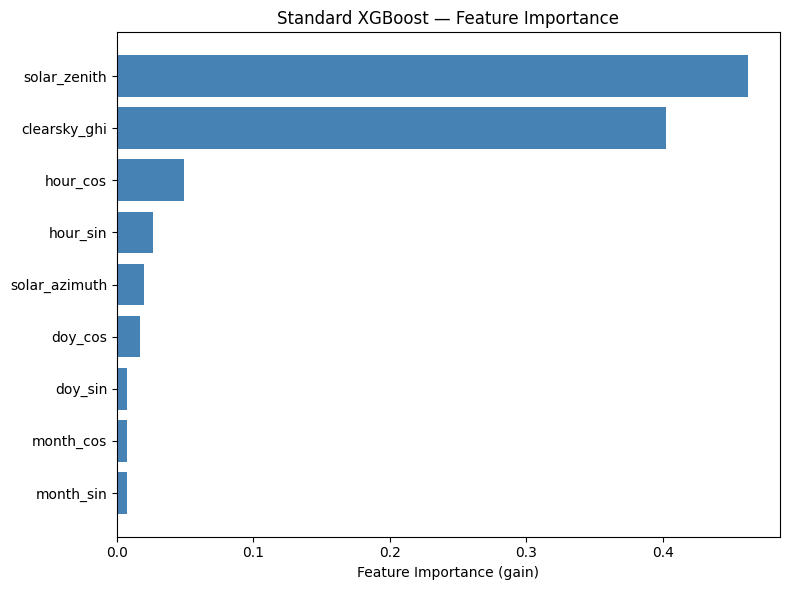

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
importance = best_model.feature_importances_
sorted_idx = np.argsort(importance)
ax.barh(range(len(sorted_idx)), importance[sorted_idx], color='steelblue')
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(np.array(FEATURES)[sorted_idx])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Standard XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

## 7. Scatter Plot & Residual Analysis (Standard)

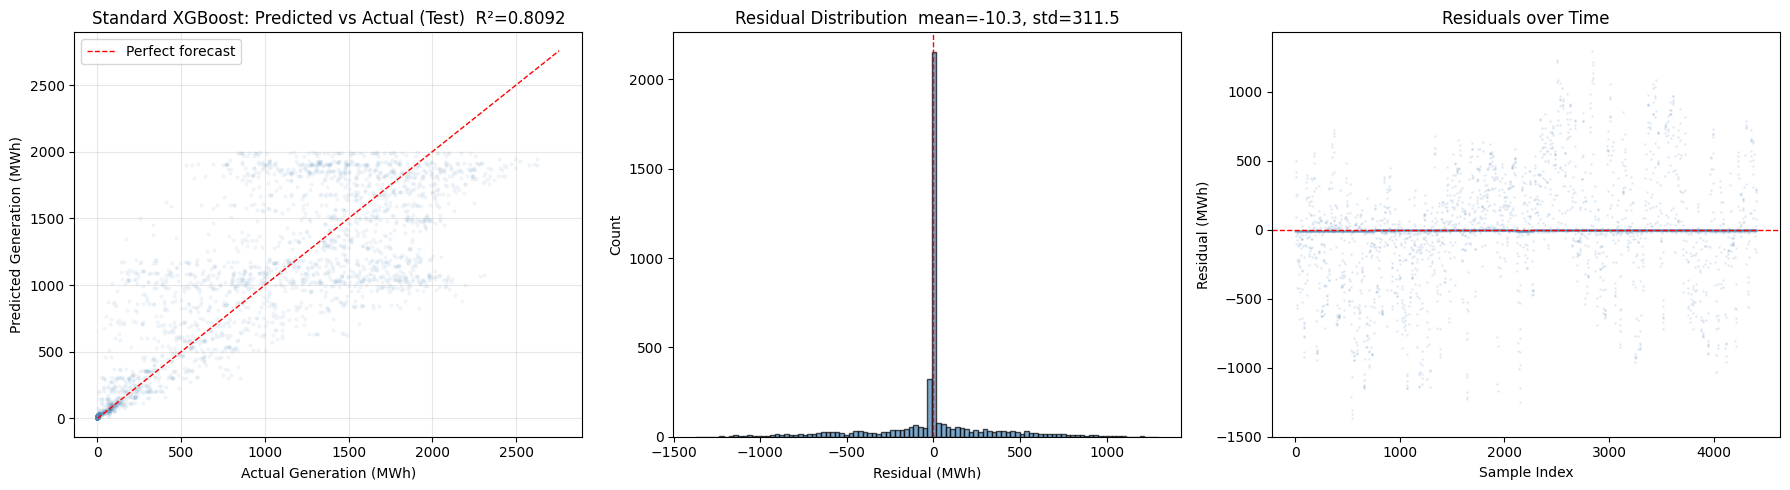

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Scatter: predicted vs actual
max_val = max(test_actual_mwh.max(), test_pred_mwh.max()) * 1.05
axes[0].scatter(test_actual_mwh, test_pred_mwh, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
axes[0].set_xlabel('Actual Generation (MWh)')
axes[0].set_ylabel('Predicted Generation (MWh)')
axes[0].set_title(f'Standard XGBoost: Predicted vs Actual (Test)  R²={test_metrics["R2"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Residual histogram
residuals = test_actual_mwh - test_pred_mwh
axes[1].hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (MWh)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  mean={residuals.mean():.1f}, std={residuals.std():.1f}')

# (c) Residual scatter
axes[2].scatter(np.arange(len(residuals)), residuals, s=1, alpha=0.1, c='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Residual (MWh)')
axes[2].set_title('Residuals over Time')

plt.tight_layout()
plt.show()

## 8. Save Standard Results

In [9]:
std_results = {
    'model': 'xgboost_standard',
    'best_trial': study.best_trial.number,
    'best_params': study.best_params,
    'n_trials': len(study.trials),
    'val_metrics_mwh': val_metrics,
    'test_metrics_mwh': test_metrics,
}

out_path = os.path.join(MODEL_DIR, 'xgboost_hp_study_results.json')
with open(out_path, 'w') as f:
    json.dump(std_results, f, indent=2)
print(f'Saved: {out_path}')

Saved: c:\Users\nicol\Documents\ML-solar-forecast\caceres\models\xgboost\xgboost_hp_study_results.json


---
# NWP Variant

Same as above but with 16 known-future features (adds 7 `_forecast` columns from Open-Meteo NWP data).
Still restricted to features available at forecast time — no observed ERA5 at the target hour.

## 9. Load NWP Data

In [10]:
nwp_train = pd.read_csv(os.path.join(DATA_DIR, 'nwp_train_processed.csv'), parse_dates=['datetime_utc'], index_col='datetime_utc')
nwp_val   = pd.read_csv(os.path.join(DATA_DIR, 'nwp_val_processed.csv'),   parse_dates=['datetime_utc'], index_col='datetime_utc')
nwp_test  = pd.read_csv(os.path.join(DATA_DIR, 'nwp_test_processed.csv'),  parse_dates=['datetime_utc'], index_col='datetime_utc')

# Load NWP preprocessing params (same target_mean/std, but has forecast feature stats)
with open(os.path.join(DATA_DIR, 'nwp_preprocessing_params.json')) as f:
    nwp_params = json.load(f)
NWP_TARGET_MEAN = nwp_params['target_mean']
NWP_TARGET_STD  = nwp_params['target_std']

# Fair comparison: only use known_future features (same as TFT NWP decoder).
# Excludes observed ERA5 weather (dewpoint_2m_C, temperature_2m_C, etc.)
# which would not be available in a real day-ahead forecast.
NWP_FEATURES = nwp_params['feature_classification']['known_future']

print(f'NWP Features ({len(NWP_FEATURES)}): {NWP_FEATURES}')
print(f'NWP Target mean: {NWP_TARGET_MEAN:.2f}, std: {NWP_TARGET_STD:.2f}')
print(f'NWP Train: {len(nwp_train)}, Val: {len(nwp_val)}, Test: {len(nwp_test)}')

X_nwp_train, y_nwp_train = nwp_train[NWP_FEATURES].values, nwp_train[TARGET].values
X_nwp_val,   y_nwp_val   = nwp_val[NWP_FEATURES].values,   nwp_val[TARGET].values
X_nwp_test,  y_nwp_test  = nwp_test[NWP_FEATURES].values,  nwp_test[TARGET].values

def denormalize_nwp(z):
    return z * NWP_TARGET_STD + NWP_TARGET_MEAN

NWP Features (16): ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'solar_zenith', 'solar_azimuth', 'clearsky_ghi', 'ssrd_wm2_forecast', 'temperature_2m_C_forecast', 'dewpoint_2m_C_forecast', 'surface_pressure_hPa_forecast', 'total_precip_mm_forecast', 'kt_forecast', 'dewpoint_depression_C_forecast']
NWP Target mean: 554.93, std: 739.48
NWP Train: 17544, Val: 4344, Test: 4416


## 10. NWP XGBoost — Optuna HP Search (15 trials)

In [11]:
def nwp_objective(trial):
    xgb_params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = xgb.XGBRegressor(**xgb_params, random_state=42, n_jobs=-1)
    model.fit(X_nwp_train, y_nwp_train, eval_set=[(X_nwp_val, y_nwp_val)], verbose=False)
    pred_z = model.predict(X_nwp_val)
    pred_mwh = np.clip(denormalize_nwp(pred_z), 0, None)
    actual_mwh = denormalize_nwp(y_nwp_val)
    rmse = np.sqrt(((actual_mwh - pred_mwh) ** 2).mean())
    return rmse


nwp_study = optuna.create_study(direction='minimize', study_name='xgb_nwp_hp')
nwp_study.optimize(nwp_objective, n_trials=15)

print(f'Best trial: #{nwp_study.best_trial.number}')
print(f'Best val RMSE (MWh): {nwp_study.best_value:.2f}')
print(f'Best params: {nwp_study.best_params}')

Best trial: #5
Best val RMSE (MWh): 299.39
Best params: {'n_estimators': 339, 'max_depth': 3, 'learning_rate': 0.0110483044666786, 'subsample': 0.9252006657286211, 'colsample_bytree': 0.9699914983095382, 'min_child_weight': 9, 'reg_alpha': 7.467257089548475e-08, 'reg_lambda': 2.24626800182976e-05}


## 11. Train Final NWP Model

In [12]:
nwp_best_model = xgb.XGBRegressor(**nwp_study.best_params, random_state=42, n_jobs=-1)
nwp_best_model.fit(X_nwp_train, y_nwp_train, eval_set=[(X_nwp_val, y_nwp_val)], verbose=False)
print('NWP XGBoost model trained with best HP.')

NWP XGBoost model trained with best HP.


## 12. Evaluate NWP Model on Val + Test

In [13]:
# Validation
nwp_val_pred_z = nwp_best_model.predict(X_nwp_val)
nwp_val_pred_mwh = np.clip(denormalize_nwp(nwp_val_pred_z), 0, None)
nwp_val_actual_mwh = denormalize_nwp(y_nwp_val)
nwp_val_metrics = compute_metrics(nwp_val_actual_mwh, nwp_val_pred_mwh)

# Test
nwp_test_pred_z = nwp_best_model.predict(X_nwp_test)
nwp_test_pred_mwh = np.clip(denormalize_nwp(nwp_test_pred_z), 0, None)
nwp_test_actual_mwh = denormalize_nwp(y_nwp_test)
nwp_test_metrics = compute_metrics(nwp_test_actual_mwh, nwp_test_pred_mwh)

print('=== NWP XGBoost — Validation ===')
print(f'  MAE:  {nwp_val_metrics["MAE_MWh"]:.2f} MWh')
print(f'  RMSE: {nwp_val_metrics["RMSE_MWh"]:.2f} MWh')
print(f'  R²:   {nwp_val_metrics["R2"]:.4f}')
print()
print('=== NWP XGBoost — Test ===')
print(f'  MAE:  {nwp_test_metrics["MAE_MWh"]:.2f} MWh')
print(f'  RMSE: {nwp_test_metrics["RMSE_MWh"]:.2f} MWh')
print(f'  R²:   {nwp_test_metrics["R2"]:.4f}')

=== NWP XGBoost — Validation ===
  MAE:  169.21 MWh
  RMSE: 299.39 MWh
  R²:   0.8709

=== NWP XGBoost — Test ===
  MAE:  126.09 MWh
  RMSE: 230.35 MWh
  R²:   0.8958


## 13. Feature Importance (NWP)

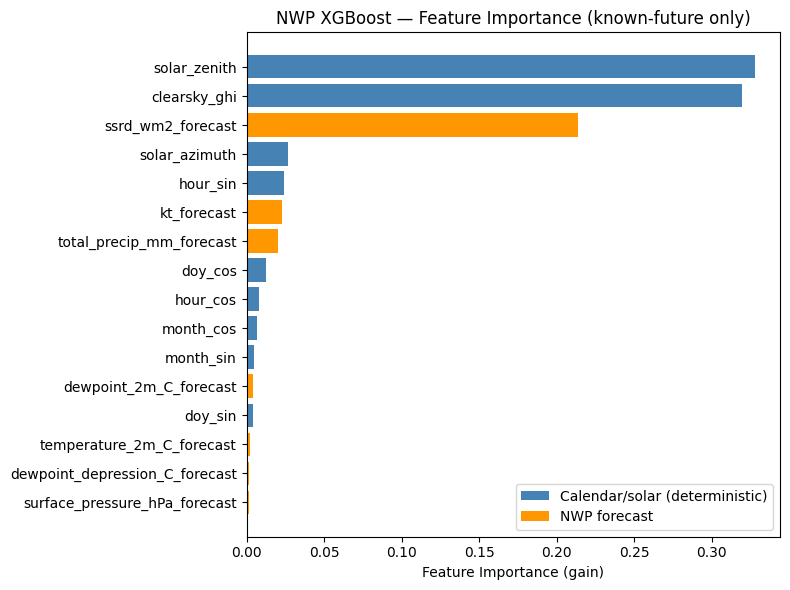

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
nwp_importance = nwp_best_model.feature_importances_
nwp_sorted_idx = np.argsort(nwp_importance)

# Color: forecast features vs deterministic (calendar/solar)
bar_colors = ['#FF9800' if '_forecast' in NWP_FEATURES[i] else 'steelblue' for i in nwp_sorted_idx]

ax.barh(range(len(nwp_sorted_idx)), nwp_importance[nwp_sorted_idx], color=bar_colors)
ax.set_yticks(range(len(nwp_sorted_idx)))
ax.set_yticklabels(np.array(NWP_FEATURES)[nwp_sorted_idx])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('NWP XGBoost — Feature Importance (known-future only)')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', label='Calendar/solar (deterministic)'),
    Patch(facecolor='#FF9800', label='NWP forecast'),
], loc='lower right')

plt.tight_layout()
plt.show()

## 14. Scatter Plot & Residual Analysis (NWP)

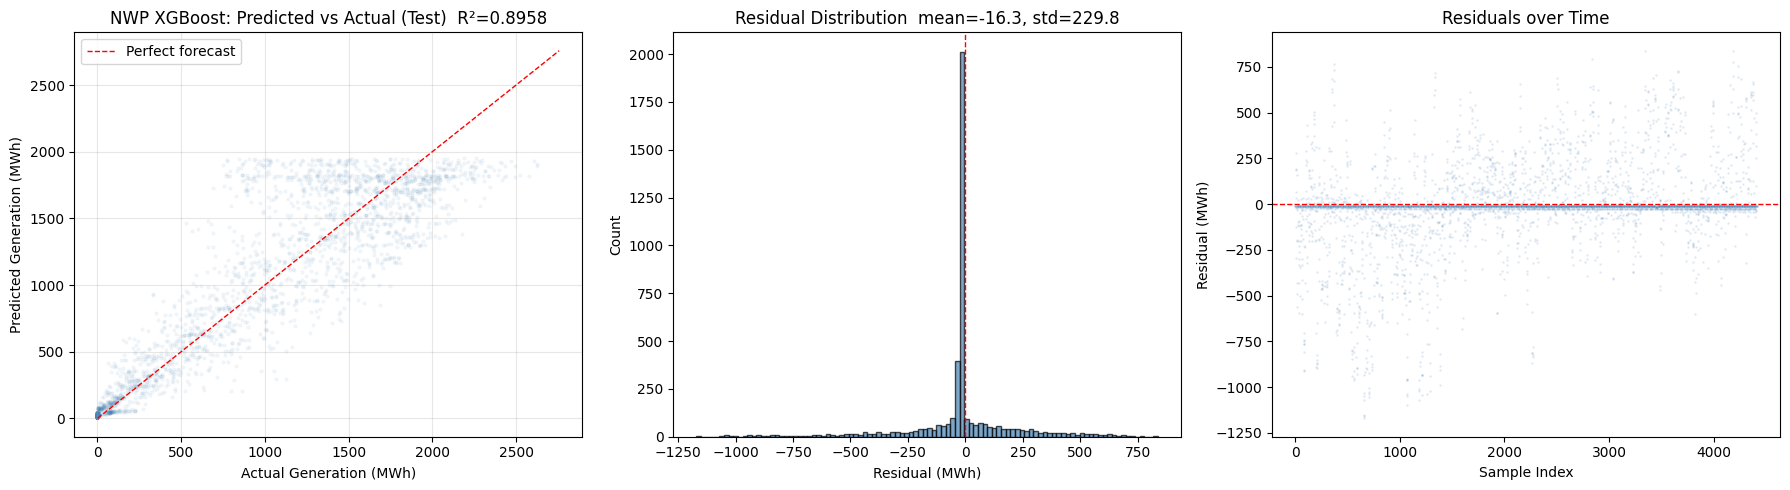

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Scatter: predicted vs actual
max_val = max(nwp_test_actual_mwh.max(), nwp_test_pred_mwh.max()) * 1.05
axes[0].scatter(nwp_test_actual_mwh, nwp_test_pred_mwh, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect forecast')
axes[0].set_xlabel('Actual Generation (MWh)')
axes[0].set_ylabel('Predicted Generation (MWh)')
axes[0].set_title(f'NWP XGBoost: Predicted vs Actual (Test)  R²={nwp_test_metrics["R2"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Residual histogram
nwp_residuals = nwp_test_actual_mwh - nwp_test_pred_mwh
axes[1].hist(nwp_residuals, bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (MWh)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  mean={nwp_residuals.mean():.1f}, std={nwp_residuals.std():.1f}')

# (c) Residual scatter
axes[2].scatter(np.arange(len(nwp_residuals)), nwp_residuals, s=1, alpha=0.1, c='steelblue')
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Residual (MWh)')
axes[2].set_title('Residuals over Time')

plt.tight_layout()
plt.show()

## 15. Save NWP Results

In [16]:
nwp_results = {
    'model': 'xgboost_nwp',
    'best_trial': nwp_study.best_trial.number,
    'best_params': nwp_study.best_params,
    'n_trials': len(nwp_study.trials),
    'val_metrics_mwh': nwp_val_metrics,
    'test_metrics_mwh': nwp_test_metrics,
}

nwp_out_path = os.path.join(MODEL_DIR, 'xgboost_nwp_hp_study_results.json')
with open(nwp_out_path, 'w') as f:
    json.dump(nwp_results, f, indent=2)
print(f'Saved: {nwp_out_path}')

Saved: c:\Users\nicol\Documents\ML-solar-forecast\caceres\models\xgboost\xgboost_nwp_hp_study_results.json


---
## 16. Side-by-Side Comparison: XGBoost vs TFT

In [17]:
# Load TFT results for comparison
tft_jsons = {
    'TFT Standard':          os.path.join(os.getcwd(), 'models', 'standard', 'hp_study_results.json'),
    'TFT NWP':               os.path.join(os.getcwd(), 'models', 'nwp_forecast', 'nwp_hp_study_results.json'),
    'TFT Perfect Forecast':  os.path.join(os.getcwd(), 'models', 'perfect_forecast', 'hp_study_results_pf.json'),
}

comparison_rows = []

# XGBoost results (already computed)
comparison_rows.append({'Model': 'XGBoost Standard', **test_metrics})
comparison_rows.append({'Model': 'XGBoost NWP',      **nwp_test_metrics})

# TFT results (from JSON)
for name, path in tft_jsons.items():
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        m = data.get('test_metrics_mwh')
        if m is None:
            print(f'  WARNING: {name} has no test_metrics_mwh — using val (rerun eval notebook!)')
            m = data.get('val_metrics_mwh')
        if m:
            comparison_rows.append({'Model': name, **m})
        else:
            print(f'  Warning: no metrics in {path}')
    else:
        print(f'  Warning: {path} not found')

comp_df = pd.DataFrame(comparison_rows)

print('=' * 65)
print('XGBoost vs TFT — Test/Val Metrics')
print('=' * 65)
print(f'{"Model":30s} {"RMSE (MWh)":>12s} {"MAE (MWh)":>11s} {"R²":>8s}')
print('-' * 65)
for _, row in comp_df.iterrows():
    print(f'{row["Model"]:30s} {row["RMSE_MWh"]:>12.2f} {row["MAE_MWh"]:>11.2f} {row["R2"]:>8.4f}')

# Highlight key deltas
xgb_std_r2 = comp_df.loc[comp_df['Model'] == 'XGBoost Standard', 'R2'].values
tft_std_r2 = comp_df.loc[comp_df['Model'] == 'TFT Standard', 'R2'].values
xgb_nwp_r2 = comp_df.loc[comp_df['Model'] == 'XGBoost NWP', 'R2'].values
tft_nwp_r2 = comp_df.loc[comp_df['Model'] == 'TFT NWP', 'R2'].values

print()
if len(xgb_std_r2) and len(tft_std_r2):
    print(f'TFT Standard vs XGBoost Standard:  ΔR² = {tft_std_r2[0] - xgb_std_r2[0]:+.4f}')
if len(xgb_nwp_r2) and len(tft_nwp_r2):
    print(f'TFT NWP vs XGBoost NWP:            ΔR² = {tft_nwp_r2[0] - xgb_nwp_r2[0]:+.4f}')

XGBoost vs TFT — Test/Val Metrics
Model                            RMSE (MWh)   MAE (MWh)       R²
-----------------------------------------------------------------
XGBoost Standard                     311.72      168.37   0.8092
XGBoost NWP                          230.35      126.09   0.8958
TFT Standard                         296.13      151.44   0.8278
TFT NWP                              236.15      119.30   0.8905
TFT Perfect Forecast                 278.23      145.50   0.8886

TFT Standard vs XGBoost Standard:  ΔR² = +0.0185
TFT NWP vs XGBoost NWP:            ΔR² = -0.0053
